# Formatting packages

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from osgeo import gdal
import xarray as xr
from scipy.io import loadmat
import scipy.stats as stats
from scipy import signal
from matplotlib.patches import Rectangle
from matplotlib import colors, colormaps
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial' # Choose a nice font here
plt.rcParams['font.size'] = 10 # standard font size
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white' # make sure background isn't transparent
plt.rcParams['figure.dpi'] = 100

# Defining Functions

In [2]:
def plot_icp_sync(icp, sync, elements):
    # Create a plot showing the continuous synchrotron concentrations over the discrete ICPOES concentrations.
    
    # Flip sync direction and convert microns to mm
    flipsync = sync.iloc[::-1].reset_index(drop=True)
    sync["mm"] = flipsync["microns"] / 1000

    # Create start and end of rectangle segments
    icp['start'] = icp['length (mm)'].cumsum().shift(fill_value=0)
    icp['end'] = icp['length (mm)'].cumsum()

    # Create a colourmap for different elements
    mass = icp["mass (g)"]
    cmap = colormaps["plasma"]
    norm = colors.Normalize(vmin = mass.min(), vmax = mass.max())

    # Create a space for the correlation coefficient
    corr_results = {}
       
    for el in elements:
        
        # Matching the ICP element column
        if el not in icp.columns:
            print(f"Skipping {el}: not found in ICP dataframe")
            continue

        # Matching the Synchrotron elements
        sync_el = el.replace("ppm/mass_", "")
        matches = [c for c in sync.columns if c.lower() == sync_el.lower()]
        if not matches:
            print(f"Skipping {el}: no matching sync column for '{sync_el}'")
            continue
        sync_el = matches[0]

        # Extracting the numeric values for both datasets and Correlation
        icp_vals = pd.to_numeric(icp[el], errors="coerce")
        sync_vals = pd.to_numeric(sync[sync_el], errors="coerce")
        corr = icp_vals.corr(sync_vals)
        corr_results[el] = corr

        # Create a scaling factor for secondary axis
        icpmax = icp_vals.max()
        syncmax = sync_vals.max()
        scale = icpmax / syncmax

        # Plotting the overlayed figures
        fig, ax1 = plt.subplots(figsize=(10, 4))

        # --- ICPOES rectangles ---
        for _, row in icp.iterrows():
            color = cmap(norm(row["mass (g)"]))
            rect = Rectangle((row["start"], 0), row["end"] - row["start"], row[el], facecolor=color, alpha=0.6, edgecolor="black", zorder=1,)
            ax1.add_patch(rect)

        # Scaled Sync line
        ax1.plot(sync["mm"], sync_vals * scale, color="black", linewidth=0.5, zorder=5,)

        # Formatting the axis for the plots
        ax1.set_xlim(0, icp["end"].max())
        ax1.set_ylim(0, icp_vals.max() * 1.05)
        ax1.set_xlabel("Whisker position (mm)")
        ax1.set_ylabel(f"{el} (ICPOES)")

        # Secondary Axis (true sync units)
        ax2 = ax1.twinx()
        ax2.set_ylim(ax1.get_ylim()[0] / scale, ax1.get_ylim()[1] / scale)
        ax2.set_ylabel(f"{sync_el} (Sync Concentration (ppm)")

        # Adding the correlation to the plots
        ax1.text(0.8, 0.95, f"r = {corr:.2f}", transform = ax1.transAxes, fontsize=12, fontweight="bold", verticalalignment="top", bbox=dict(facecolor="white", alpha = 0.6, edgecolor = "none"))

        # Add a colourbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([]) # required for Matplotlib
        cbar = fig.colorbar(sm, ax=ax1, pad = 0.1)
        cbar.set_label("Mass (g)")

def parascatter(df,xs,ys,xerrs=None,yerrs=None, size=5,
                ss=3, lw=0.5, color='black' , scale='linear', wspace=0.3, hspace=0.4, alpha =0.6, fitted=True):
    # xs = list of elements to vary in each row
    # xy = list of elements to vary in each column
    #xerrs and yerrs = data errors (contitional variable, only activated if present)
    labels = {'Ca':'Calcium (ppb)', 'Sr':'Strontium (ppb)', 'Mn':'Manganese (ppb)', 'Fe':'Iron (ppb)'}
    
    plt.figure(figsize=(len(ys)*size,len(xs)*size))
    for i in range(len(xs)): # loop everything in rows
        for j in range(len(ys)): # loop everything in columns
            ax = plt.subplot(len(xs),len(ys),j+i*len(ys)+1) # automating the same subplot figure positioning (3, 4, 1)
            
            x = df[xs[i]].values
            y = df[ys[j]].values
            ax.scatter(x, y, s=ss, color = color, alpha=1, lw=lw)

            # if error bars are here, plot them as lines for both x and y.
         
            if xerrs: 
                plt.plot([df[xs[i]]-df[xerrs[i]],df[xs[i]]+df[xerrs[i]]],
                         [df[ys[j]],df[ys[j]]],
                         color=color,lw=lw)
            if yerrs:
                plt.plot([df[xs[i]],df[xs[i]]],
                         [df[ys[j]]-df[yerrs[j]],df[ys[j]]+df[yerrs[j]]],
                         color=color,lw=lw)
            if fitted:
                fit = np.polyfit(x, y, 1)
                slope, intercept = fit
                x_values = np.linspace(np.min(x), np.max(x), 200)
                yfit = np.polyval(fit, x_values)
                ax.plot(x_values, yfit, color='blue', lw=1.5)
                r2 = get_r2(x, y)
                ax.text(0.1, 0.9, f"y= {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.2f}", ha='left', va='top',
                        transform=ax.transAxes, fontsize=9, color='blue')
                
            ax.set_xscale(scale)
            ax.set_yscale(scale)
            ax.set_xlabel(labels.get(xs[i], xs[i]))
            ax.set_ylabel(labels.get(ys[j], ys[j]))
    plt.subplots_adjust(wspace=wspace,hspace=hspace)


def get_r2(x,y):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

def get_powerlaw_constants(x,y):
    polyfit = np.polyfit(np.log10(x),np.log10(y),1)
    l,n = 10**polyfit[1],polyfit[0]
    return l,n

def plot_power_spectra(df, elements, wspace=0.3, hspace=0.4):
    cm = np.asarray(sync.microns/10000)
    fs = 1/np.diff(cm)[0]
    f_minbound = 2.5e-5

    n = len(elements)
    fig, axes = plt.subplots(n, 1, figsize=(7, 3*n), sharex=False)

    for ax, elem in zip(axes, elements):
        y = np.asarray(sync[elem][::-1])
        # Welch (no smoothing)
        f, PUU = signal.welch(y, fs, nperseg=len(cm), scaling = 'spectrum')
        # Welch (smoothing)
        f_smooth, PUU_smooth = signal.welch(y, fs, nperseg=int(len(cm)/20), scaling = 'spectrum')

        l_smooth, n_smooth = get_powerlaw_constants(f_smooth[f_smooth>f_minbound], PUU_smooth[f_smooth>f_minbound])

        ax.plot(f_smooth, PUU_smooth, label = f"{elem} spectrum")
        ax.plot(f_smooth[f_smooth>f_minbound], l_smooth*f_smooth[f_smooth>f_minbound]**n_smooth, label = f"n = {n_smooth:.2f}")

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylabel(f"{elem} power (ppb$^2$/cm)")
        ax.set_xlabel('frequency (1/cm)')
        ax.legend(frameon=False)
        ax.grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.subplots_adjust(wspace=wspace,hspace=hspace)
        
        
def plot_icp_only(icp, elements):
    # Create start and end of rectangle segments
    icp['start'] = icp['length (mm)'].cumsum().shift(fill_value=0)
    icp['end'] = icp['length (mm)'].cumsum()

    # Colourmap based on mass
    mass = icp["mass (g)"]
    cmap = colormaps["plasma"]
    norm = colors.Normalize(vmin=mass.min(), vmax=mass.max())

    for el in elements:

        # Ensure element exists
        if el not in icp.columns:
            print(f"Skipping {el}: not found in ICP dataframe")
            continue

        icp_vals = pd.to_numeric(icp[el], errors="coerce")

        # Create figure
        fig, ax = plt.subplots(figsize=(10, 4))

        # --- ICPOES rectangles only ---
        for _, row in icp.iterrows():
            color = cmap(norm(row["mass (g)"]))
            rect = Rectangle(
                (row["start"], 0),
                row["end"] - row["start"],
                row[el],
                facecolor=color,
                alpha=0.6,
                edgecolor="black",
                zorder=1,)
            ax.add_patch(rect)

        # Axis formatting
        ax.set_xlim(0, icp["end"].max())
        ax.set_ylim(0, icp_vals.max() * 1.05)
        ax.set_xlabel("Whisker position (mm)")
        ax.set_ylabel(f"{el} (ICPOES)")
        ax.set_title(f"ICPOES Rectangle Plot: {el}")

        # --- COLORBAR ---
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.1)
        cbar.set_label("Mass (g)")
        

# Loading data and arrays

In [3]:
sync = pd.read_csv('./data/sync_whisker_narrow_working.csv')
icp = pd.read_csv('./data/Whisker_120_analysis_ICPOES.csv')

In [4]:
# turn data into arrays
microns = sync['microns']
Sr = sync['Sr']
Ca = sync['Ca']
cm = sync['microns']/10000
um = sync['microns']

# Flipping the synchrotron data
flipsync = sync.iloc[::-1].reset_index(drop=True)
sync["mm"] = flipsync["microns"] / 1000

# Synchrotron Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

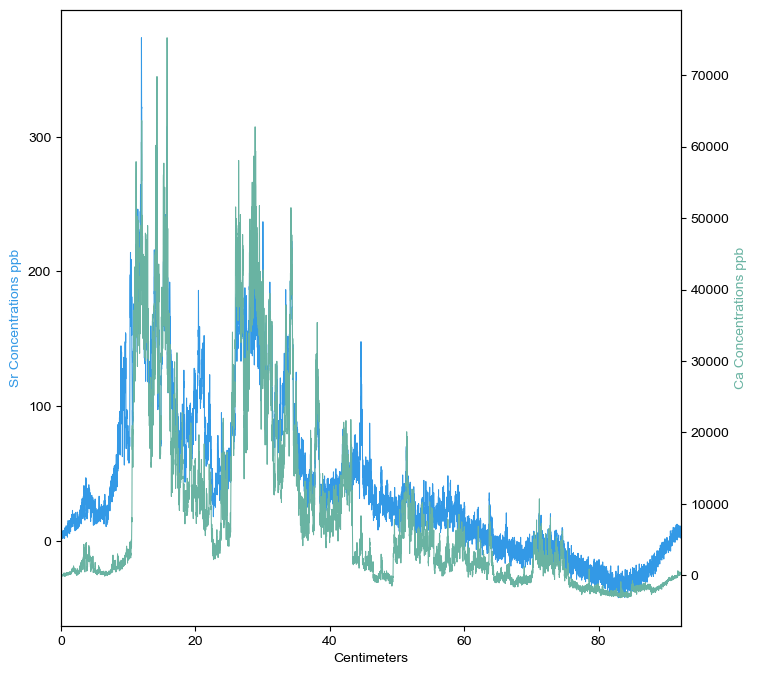

In [5]:
COLOR_CA = "#69b3a2"
COLOR_SR = "#3399e6"

fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

ax1.plot(sync["mm"], Sr, color=COLOR_SR, lw=0.75)
ax2.plot(sync["mm"], Ca, color=COLOR_CA, lw=0.75)

ax1.set_xlabel("Centimeters")
ax1.set_ylabel("Sr Concentrations ppb", color=COLOR_SR)
ax2.set_ylabel("Ca Concentrations ppb", color=COLOR_CA)
ax1.set_xlim(0, sync["mm"].max())

plt.show

# Synchrotron Elemental Relationships

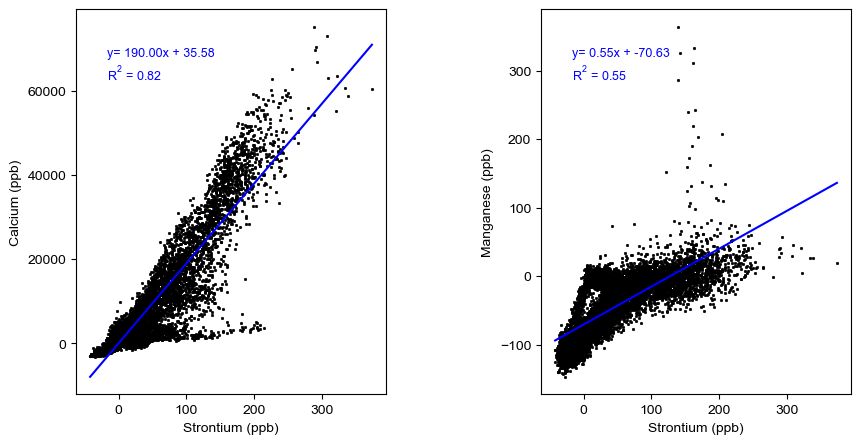

In [6]:
# calling the parscatter function, with the elements for rows, and the elements for columns
parascatter(sync,['Sr'],['Ca','Mn'])
plt.subplots_adjust(hspace=0.5, wspace=0.5)

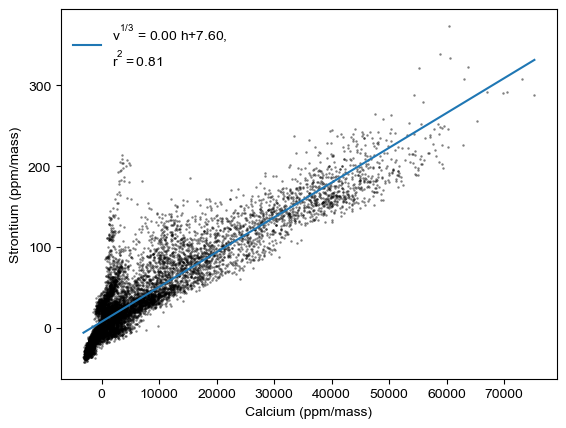

In [7]:
ss = 3
plt.scatter(Ca,Sr,c='k',s=ss,alpha=0.5,lw=0)
x_values = np.arange(np.min(Ca), np.max(Ca),1) # created series of x values
fit = np.polyfit(Ca, Sr,1) # creating fit for data
yfit = np.polyval(fit, x_values) # create corresponding y values for x values
plt.plot(x_values, yfit, label='v$^{1/3}$ = %.2f h+%.2f,\nr$^2=%.2f$'%(fit[0],fit[1],get_r2(Ca,np.abs(Sr)))) # plots y against x
plt.xlabel('Calcium (ppm/mass)')
plt.ylabel('Strontium (ppm/mass)')
plt.legend(frameon=False)

# ICP-OES Elemental Relationships

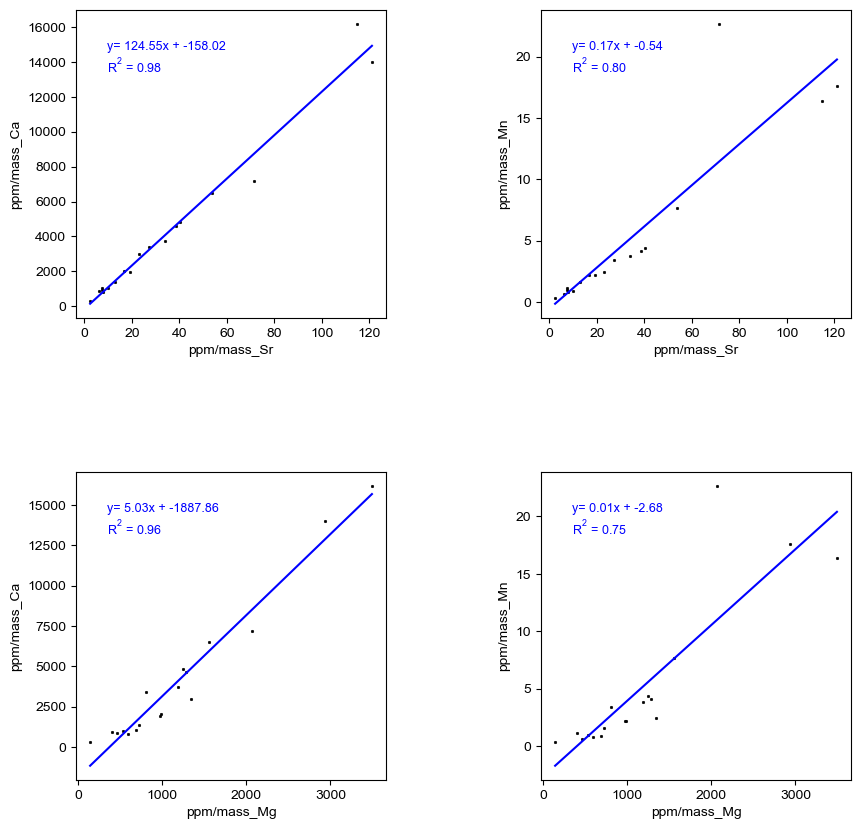

In [8]:
parascatter(icp,['ppm/mass_Sr', 'ppm/mass_Mg'],['ppm/mass_Ca','ppm/mass_Mn'])
plt.subplots_adjust(hspace=0.5, wspace=0.5)

# Power Spectra Analysis

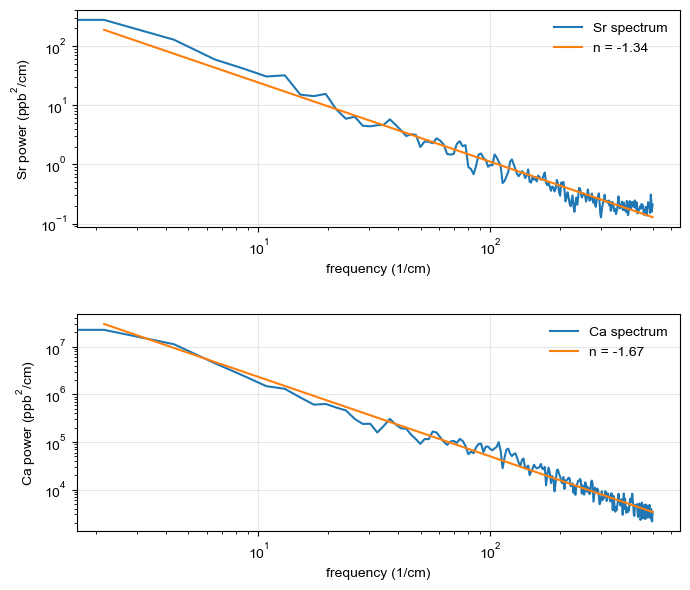

In [9]:
plot_power_spectra(sync, ['Sr', 'Ca'])

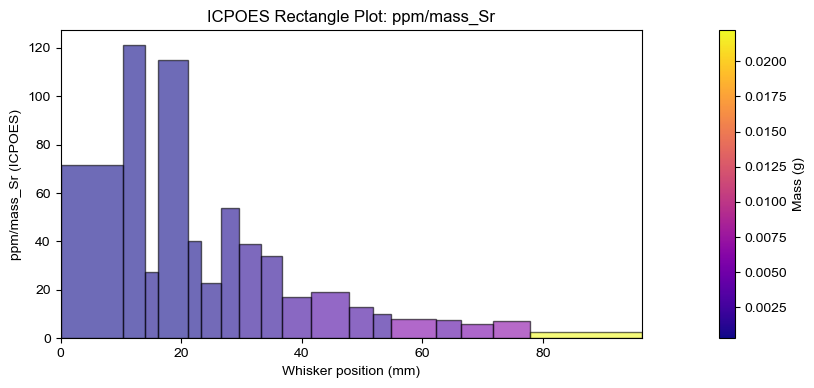

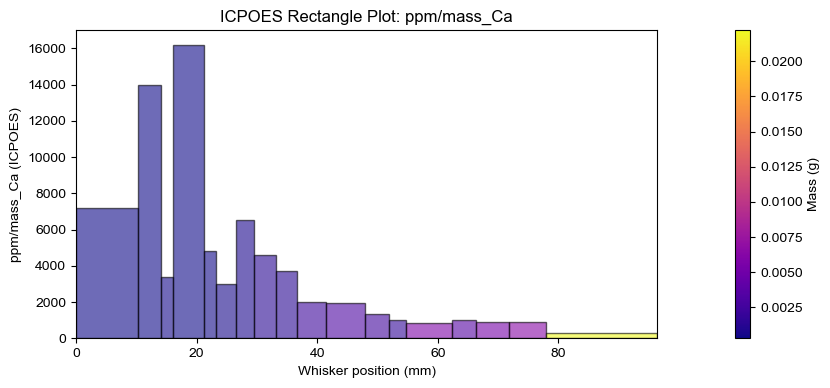

In [10]:
elements = ["ppm/mass_Sr", "ppm/mass_Ca"]
plot_icp_only(icp, elements)

# Plotting the overlapping datasets

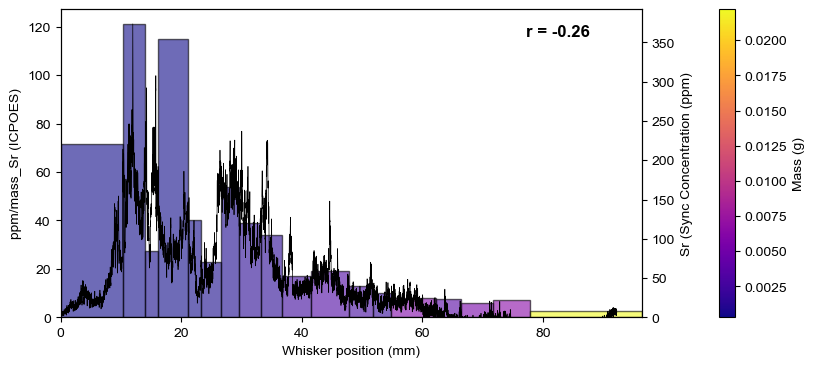

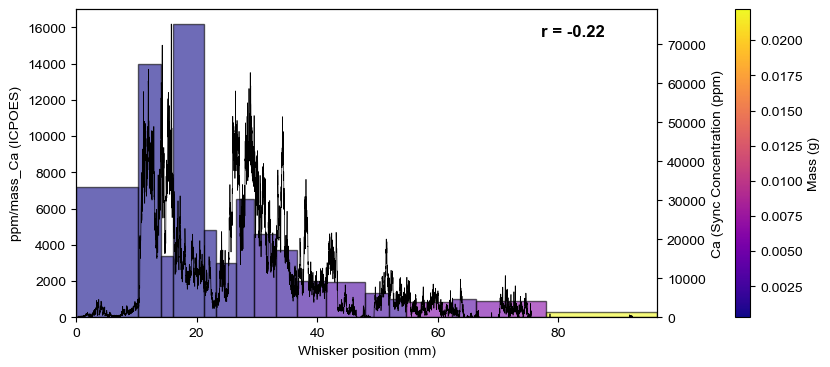

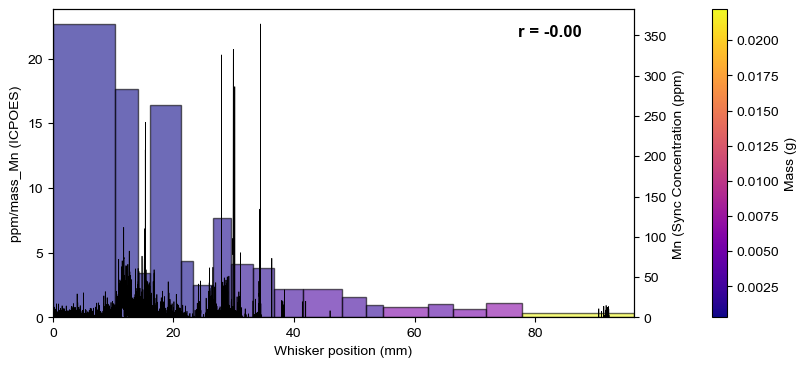

In [11]:
elements = ["ppm/mass_Sr", "ppm/mass_Ca", "ppm/mass_Mn"]
plot_icp_sync(icp, sync, elements)

# Printing publication graphs

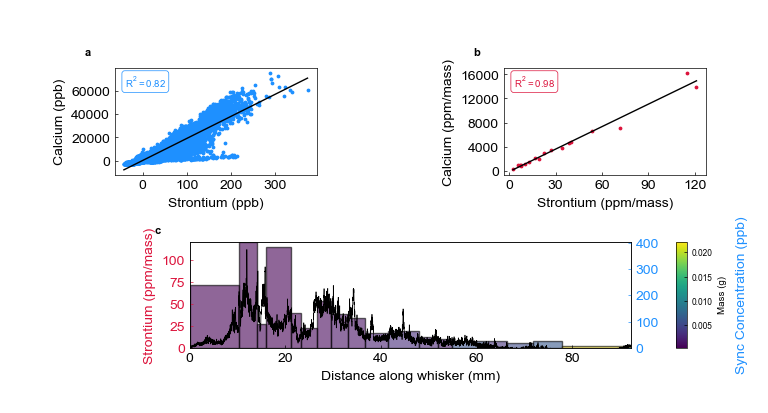

In [12]:
draft = False

lw = 0.5 #pt

ts = sync['microns'][::-1]/1000
scale = 0.3
hbuf = 0.05
wbuf = 0.25
cbh  = 0.01
pltspan = 0.27
blowbuf = 0.1
labbuf  = 0.1
sync_col = 'dodgerblue'
icp_col = 'crimson'
icp['start'] = icp['length (mm)'].cumsum().shift(fill_value=0)
icp['end'] = icp['length (mm)'].cumsum()
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(icp["mass (g)"].min(), icp["mass (g)"].max())


ax0l,ax0b,ax0w,ax0h = 0.14,0.58,pltspan,pltspan
cb0l,cb0b,cb0w,cb0h = ax0l,ax0b+ax0h+hbuf,ax0w,cbh
ax1l,ax1b,ax1w,ax1h = ax0l+ax0w+wbuf,ax0b,ax0w,ax0h
cb1l,cb1b,cb1w,cb1h = ax1l,ax1b+ax1h+hbuf,ax1w,cbh
ax2l,ax2b,ax2w,ax2h = ax0l+blowbuf,0.14,ax0w*2+wbuf-2*blowbuf,ax0h


boxheight = 0.1

fig = plt.gcf()
fig.clear()
plt.subplots_adjust(left=0.1, right=0.88, top=0.95, bottom=0.1)

ax00 = fig.add_axes([0,0,1,1])
ax00.patch.set_alpha(0)
ax00.set_zorder(1)

if draft:
    plt.xticks([])
    plt.yticks([])
else:
    plt.axis('off')

# Panel A
ax0 = fig.add_axes([ax0l,ax0b,ax0w,ax0h])
ax0.scatter(sync['Sr'], sync['Ca'], s=3, color=sync_col)

sx = sync['Sr'].values
sy = sync['Ca'].values
sfit = np.polyfit(sx, sy, 1)
sxfit = np.linspace(sx.min(), sx.max(), 200)
syfit = np.polyval(sfit, sxfit)

ax0.plot(sxfit, syfit, color='black', lw=1)

sy_pred = np.polyval(sfit, sx)
sr2 = 1 - np.sum((sy - sy_pred)**2) / np.sum((sy - sy.mean())**2)

ax0.text(0.05, 0.95, f"$R^2 = {sr2:.2f}$", transform=ax0.transAxes, ha='left', va='top', 
         color=sync_col, fontsize=7,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=sync_col, linewidth=0.5))
ax0.text(-0.15, 1.12, 'a', fontsize=8, weight='bold', transform=ax0.transAxes,)

ax0.set_xlabel('Strontium (ppb)')
ax0.set_ylabel('Calcium (ppb)')


# Panel B
ax1 = fig.add_axes([ax1l,ax1b,ax1w,ax1h])
ax1.scatter(icp['ppm/mass_Sr'], icp['ppm/mass_Ca'], s=3, color=icp_col)

ix = icp['ppm/mass_Sr'].values
iy = icp['ppm/mass_Ca'].values
ifit = np.polyfit(ix, iy, 1)
ixfit = np.linspace(ix.min(), ix.max(), 200)
iyfit = np.polyval(ifit, ixfit)
ax1.plot(ixfit, iyfit, color='black', lw=1)
iy_pred = np.polyval(ifit, ix)
ir2 = 1 - np.sum((iy - iy_pred)**2) / np.sum((iy - iy.mean())**2)

ax1.text(0.05, 0.95, f"$R^2 = {ir2:.2f}$", transform=ax1.transAxes, ha='left', va='top', 
         color=icp_col, fontsize=7,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=icp_col, linewidth=0.5))
ax1.text(-0.15, 1.12, 'b', fontsize=8, weight='bold', transform=ax1.transAxes)

ax1.set_xlabel('Strontium (ppm/mass)')
ax1.set_ylabel('Calcium (ppm/mass)')

# Panel C (ICPOES)
ax2 = fig.add_axes([ax2l, ax2b, ax2w, ax2h])
for _, row in icp.iterrows():
    color = cmap(norm(row["mass (g)"]))
    rect = Rectangle(
        (row["start"], 0),
        row["end"] - row["start"],
        row['ppm/mass_Sr'],
        facecolor=color,
        alpha=0.6,
        edgecolor="black",
        zorder=1)
    ax2.add_patch(rect)
ax2.plot(ts, sync['Sr']*scale, lw=lw, color='black', zorder=3)
ax2.set_xlim(ts.min(), ts.max())
ax2.set_xlabel('Distance along whisker (mm)')
ax2.set_ylim(0, (icp['ppm/mass_Sr'].max()))
ax2.set_ylabel('Strontium (ppm/mass)', color=icp_col)
ax2.tick_params(axis='y', colors=icp_col)
ax2.text(-0.08, 1.08, 'c', fontsize=8, weight='bold', transform=ax2.transAxes)

# Panel C (Sync)
ax3 = ax2.twinx()
ax3.set_ylim(ax2.get_ylim()[0] / scale, ax2.get_ylim()[1] / scale)
ax3.set_ylabel("Sync Concentration (ppb)", color=sync_col, labelpad=55)
ax3.tick_params(axis='y', colors=sync_col)

# Colourbar for Panel C
cb_ax = fig.add_axes([ax2l + ax2w + 0.06, ax2b, 0.015, ax2h])
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cb_ax)
cbar.set_label('Mass (g)', fontsize=7)
cbar.ax.tick_params(labelsize=6, width=lw, length=lw*3)
cbar.outline.set_linewidth(lw)

# Tick marks
for ax in [ax0, ax1, ax2, ax3]:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=False))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=False))

# Styling
for ax in fig.axes:
    ax.tick_params(width=lw,length=lw*5,which='both',direction='in')
    ax.minorticks_off()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(lw)

fig.set_size_inches(190/25.4,100/25.4, forward=True)
if draft==False:
    plt.savefig('abstractplot.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('abstractplot.png', dpi=300, bbox_inches='tight')